# Southern Women Network Analysis
### Marc Fridson | CUNY SPS

The Davis Southern Women dataset comes from a 1941 study by Davis, Gardner, and Gardner (*Deep South*), tracking the attendance of 18 women at 14 social events in Natchez, Mississippi. It's a classic **bipartite network**: women on one side, events on the other, edges representing attendance. Despite its small size, this "musty" dataset remains a benchmark for community detection and clustering algorithms because researchers have consistently found two core social groups, making it ideal for validating new methods.

The goal here is to project this bipartite network onto both node sets, run community detection and centrality analysis on each, and see what the attendance patterns tell us about relationships between the women and between the events.

## 1. Setup and Data Loading

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.algorithms import bipartite
import community as community_louvain
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Load dataset from NetworkX
# Ref: https://networkx.github.io/documentation/stable/auto_examples/algorithms/plot_davis_club.html
G = nx.davis_southern_women_graph()

women = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
events = set(G) - women
women_sorted = sorted(women)
events_sorted = sorted(events)

print(f"Women: {len(women)}, Events: {len(events)}, Edges: {G.number_of_edges()}")
print(f"Density: {bipartite.density(G, women):.3f}")

Women: 18, Events: 14, Edges: 89
Density: 0.353


## 2. Bipartite Network and Attendance Matrix

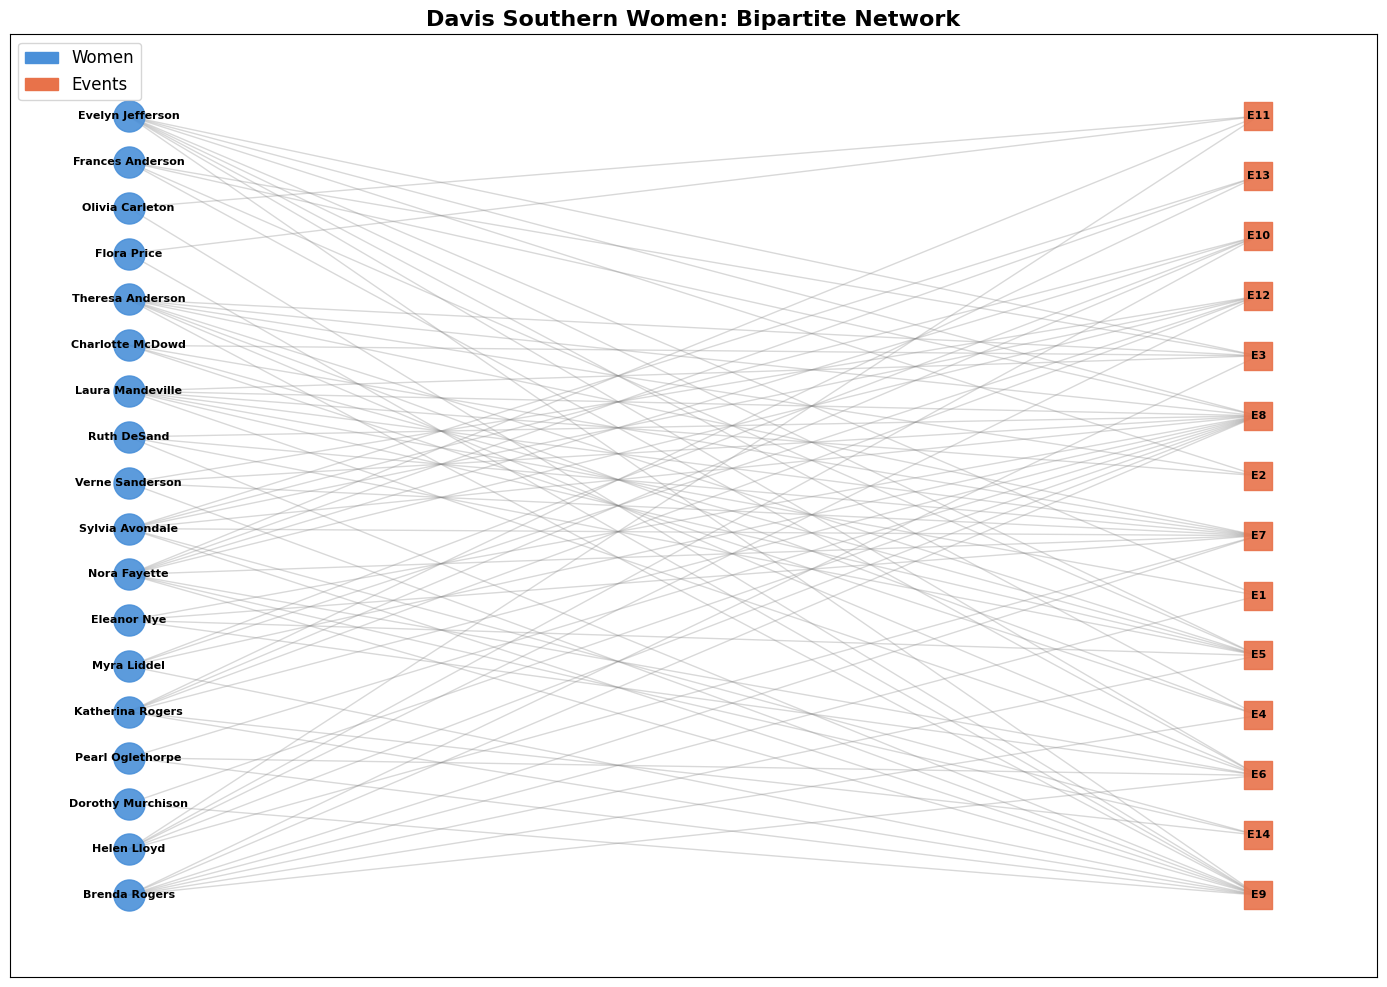

In [2]:
# Bipartite layout
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.bipartite_layout(G, women, align='vertical', scale=2)

nx.draw_networkx_nodes(G, pos, nodelist=women_sorted, node_color='#4A90D9',
                       node_size=500, alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=events_sorted, node_color='#E8724A',
                       node_size=400, node_shape='s', alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

ax.legend(handles=[mpatches.Patch(color='#4A90D9', label='Women'),
                   mpatches.Patch(color='#E8724A', label='Events')], loc='upper left', fontsize=12)
ax.set_title('Davis Southern Women: Bipartite Network', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

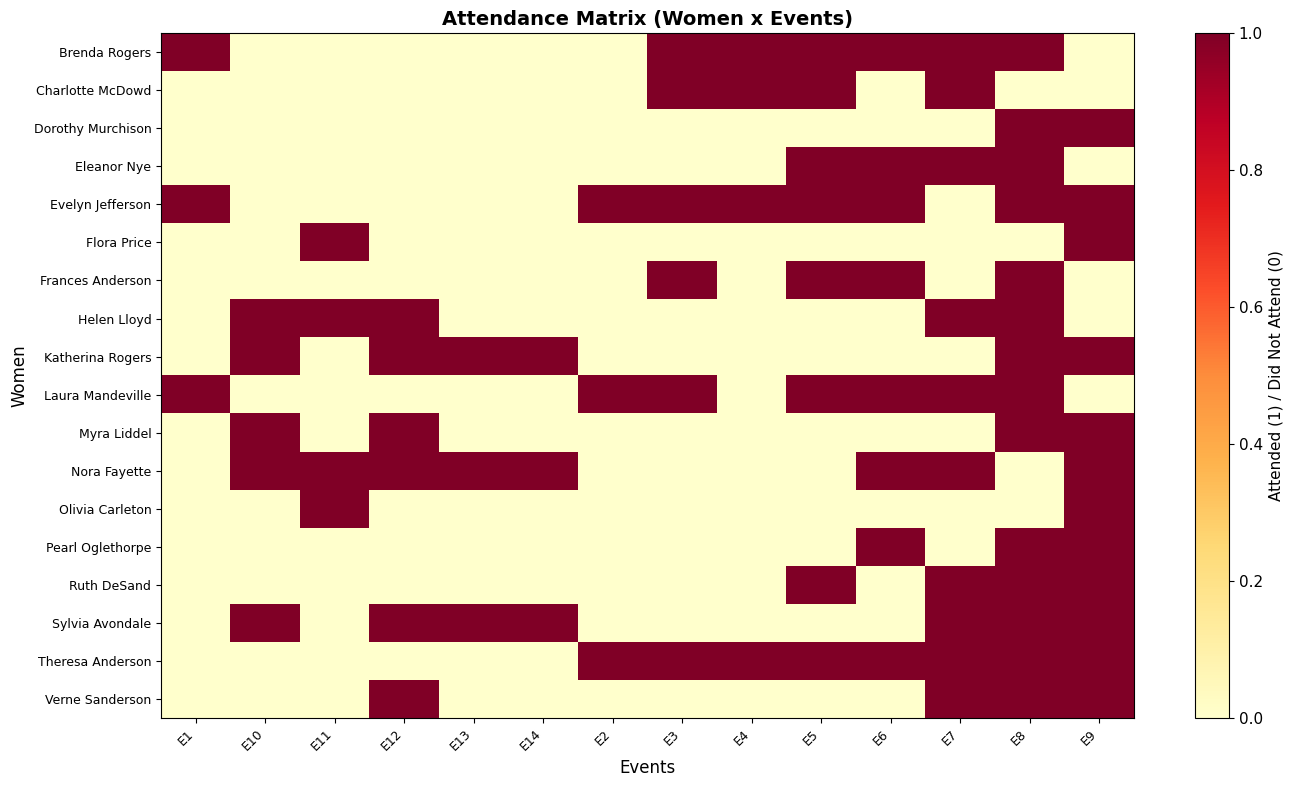

Events attended per woman:
  Brenda Rogers: 7
  Charlotte McDowd: 4
  Dorothy Murchison: 2
  Eleanor Nye: 4
  Evelyn Jefferson: 8
  Flora Price: 2
  Frances Anderson: 4
  Helen Lloyd: 5
  Katherina Rogers: 6
  Laura Mandeville: 7
  Myra Liddel: 4
  Nora Fayette: 8
  Olivia Carleton: 2
  Pearl Oglethorpe: 3
  Ruth DeSand: 4
  Sylvia Avondale: 7
  Theresa Anderson: 8
  Verne Sanderson: 4

Women per event:
  E1: 3
  E10: 5
  E11: 4
  E12: 6
  E13: 3
  E14: 3
  E2: 3
  E3: 6
  E4: 4
  E5: 8
  E6: 8
  E7: 10
  E8: 14
  E9: 12


In [3]:
# Attendance matrix
adj_matrix = bipartite.biadjacency_matrix(G, row_order=women_sorted, column_order=events_sorted).toarray()

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(adj_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(events_sorted)))
ax.set_xticklabels(events_sorted, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(women_sorted)))
ax.set_yticklabels(women_sorted, fontsize=9)
ax.set_xlabel('Events', fontsize=12)
ax.set_ylabel('Women', fontsize=12)
ax.set_title('Attendance Matrix (Women x Events)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Attended (1) / Did Not Attend (0)')
plt.tight_layout()
plt.show()

print("Events attended per woman:")
for i, w in enumerate(women_sorted):
    print(f"  {w}: {adj_matrix[i].sum():.0f}")

print(f"\nWomen per event:")
for j, e in enumerate(events_sorted):
    print(f"  {e}: {adj_matrix[:, j].sum():.0f}")

## 3. Women Network: Projection, Communities, and Centrality

Projecting onto women nodes, where two women get an edge if they co-attended at least one event, weighted by the number of shared events.

In [4]:
# Project and detect communities
W = bipartite.weighted_projected_graph(G, women)
partition_women = community_louvain.best_partition(W, random_state=42)

print(f"Women network: {W.number_of_nodes()} nodes, {W.number_of_edges()} edges, density: {nx.density(W):.3f}")
print(f"Communities: {len(set(partition_women.values()))}, Modularity: {community_louvain.modularity(partition_women, W):.3f}")
print(f"Transitivity: {nx.transitivity(W):.3f}, Avg clustering: {nx.average_clustering(W, weight='weight'):.3f}")

print(f"\nTop co-attendance pairs:")
for u, v, d in sorted(W.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:8]:
    print(f"  {u} -- {v}: {d['weight']} shared events")

communities = set(partition_women.values())
for c in sorted(communities):
    members = [n for n, comm in partition_women.items() if comm == c]
    print(f"\nGroup {c+1}: {sorted(members)}")

Women network: 18 nodes, 139 edges, density: 0.908
Communities: 2, Modularity: 0.152
Transitivity: 0.928, Avg clustering: 0.289

Top co-attendance pairs:
  Theresa Anderson -- Evelyn Jefferson: 7 shared events
  Brenda Rogers -- Laura Mandeville: 6 shared events
  Brenda Rogers -- Theresa Anderson: 6 shared events
  Brenda Rogers -- Evelyn Jefferson: 6 shared events
  Laura Mandeville -- Theresa Anderson: 6 shared events
  Laura Mandeville -- Evelyn Jefferson: 6 shared events
  Katherina Rogers -- Sylvia Avondale: 6 shared events
  Nora Fayette -- Sylvia Avondale: 6 shared events

Group 1: ['Brenda Rogers', 'Charlotte McDowd', 'Eleanor Nye', 'Evelyn Jefferson', 'Frances Anderson', 'Laura Mandeville', 'Ruth DeSand', 'Theresa Anderson']

Group 2: ['Dorothy Murchison', 'Flora Price', 'Helen Lloyd', 'Katherina Rogers', 'Myra Liddel', 'Nora Fayette', 'Olivia Carleton', 'Pearl Oglethorpe', 'Sylvia Avondale', 'Verne Sanderson']


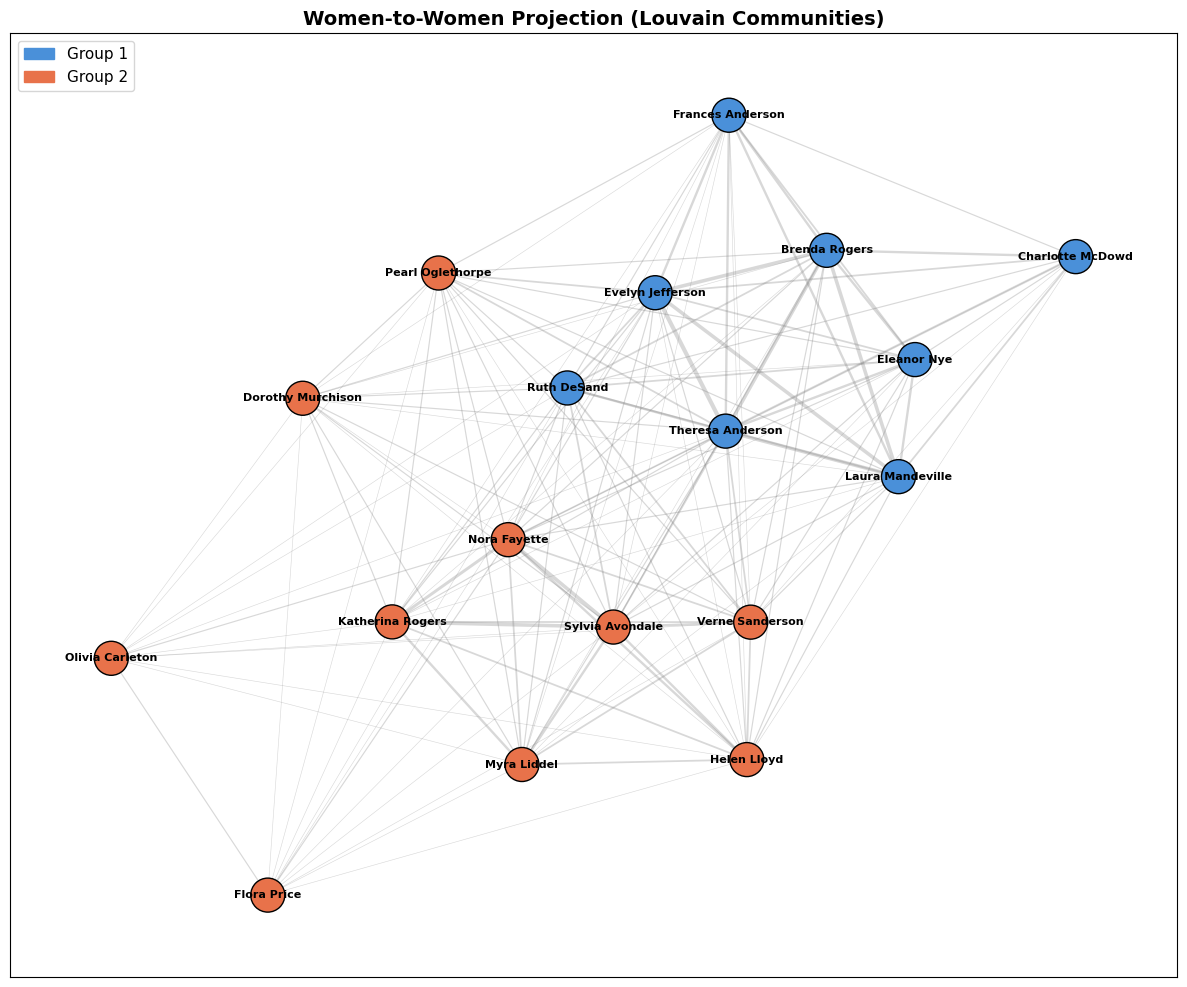

In [5]:
# Visualize women network with communities
community_colors_map = {0: '#4A90D9', 1: '#E8724A', 2: '#50C878', 3: '#9B59B6'}
node_colors_w = [community_colors_map.get(partition_women[n], '#888888') for n in W.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
pos_w = nx.spring_layout(W, seed=42, k=0.8)
edges = W.edges(data=True)
edge_weights = [d['weight'] for _, _, d in edges]
max_w = max(edge_weights)

nx.draw_networkx_edges(W, pos_w, alpha=0.3, width=[w/max_w*3 for w in edge_weights], edge_color='gray', ax=ax)
nx.draw_networkx_nodes(W, pos_w, node_color=node_colors_w, node_size=600, edgecolors='black', linewidths=1.0, ax=ax)
nx.draw_networkx_labels(W, pos_w, font_size=8, font_weight='bold', ax=ax)

patches = [mpatches.Patch(color=community_colors_map[c], label=f'Group {c+1}') for c in sorted(communities)]
ax.legend(handles=patches, loc='upper left', fontsize=11)
ax.set_title('Women-to-Women Projection (Louvain Communities)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Centrality measures
deg_cent_w = nx.degree_centrality(W)
betw_cent_w = nx.betweenness_centrality(W, weight='weight')
close_cent_w = nx.closeness_centrality(W)
eigen_cent_w = nx.eigenvector_centrality(W, weight='weight', max_iter=1000)

print(f"{'Woman':<20} {'Degree':>8} {'Betweenness':>12} {'Closeness':>10} {'Eigenvector':>12}")
print("-" * 65)
for w in women_sorted:
    print(f"{w:<20} {deg_cent_w[w]:>8.3f} {betw_cent_w[w]:>12.3f} {close_cent_w[w]:>10.3f} {eigen_cent_w[w]:>12.3f}")

print(f"\nMost central by eigenvector: {max(eigen_cent_w, key=eigen_cent_w.get)}")
print(f"Most central by betweenness: {max(betw_cent_w, key=betw_cent_w.get)}")

Woman                  Degree  Betweenness  Closeness  Eigenvector
-----------------------------------------------------------------
Brenda Rogers           0.882        0.003      0.895        0.304
Charlotte McDowd        0.647        0.015      0.739        0.174
Dorothy Murchison       0.941        0.096      0.944        0.146
Eleanor Nye             0.882        0.005      0.895        0.239
Evelyn Jefferson        1.000        0.001      1.000        0.319
Flora Price             0.706        0.136      0.773        0.077
Frances Anderson        0.882        0.058      0.895        0.218
Helen Lloyd             1.000        0.062      1.000        0.207
Katherina Rogers        0.941        0.054      0.944        0.222
Laura Mandeville        0.882        0.003      0.895        0.300
Myra Liddel             0.941        0.054      0.944        0.198
Nora Fayette            1.000        0.011      1.000        0.253
Olivia Carleton         0.706        0.136      0.773        0.

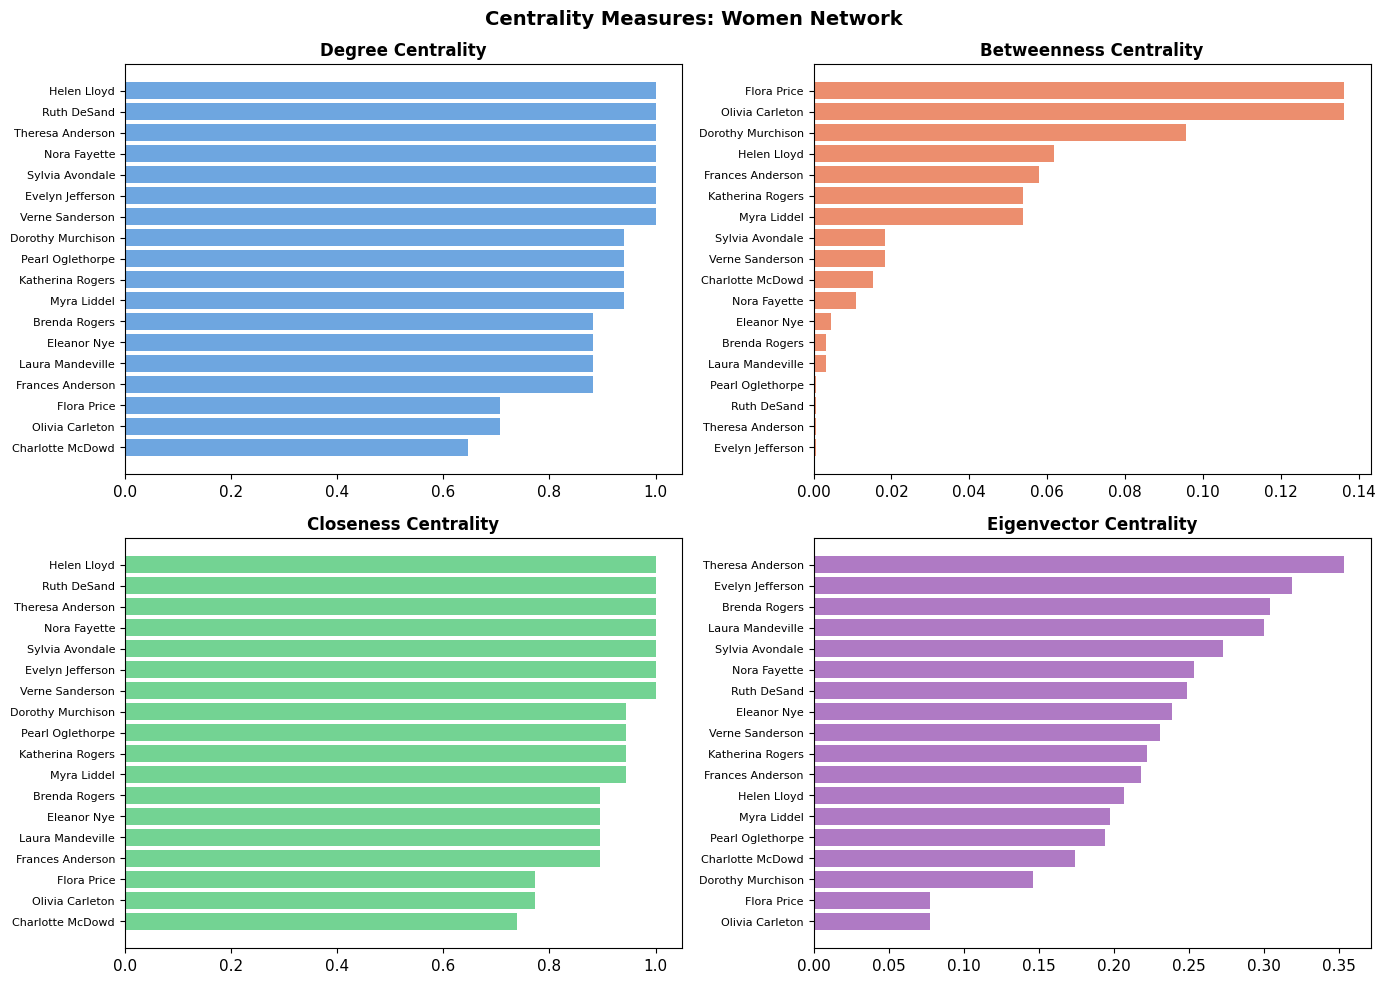

In [7]:
# Centrality comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
centralities = [
    (deg_cent_w, 'Degree Centrality', '#4A90D9'),
    (betw_cent_w, 'Betweenness Centrality', '#E8724A'),
    (close_cent_w, 'Closeness Centrality', '#50C878'),
    (eigen_cent_w, 'Eigenvector Centrality', '#9B59B6')
]
for ax, (cent, title, color) in zip(axes.flatten(), centralities):
    sorted_items = sorted(cent.items(), key=lambda x: x[1], reverse=True)
    names = [x[0] for x in sorted_items]
    values = [x[1] for x in sorted_items]
    ax.barh(range(len(names)), values, color=color, alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Centrality Measures: Women Network', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Events Network: Projection, Communities, and Centrality

Same approach flipped: two events are connected if they share at least one attendee, weighted by the number of shared women.

In [8]:
# Project and detect communities
E = bipartite.weighted_projected_graph(G, events)
partition_events = community_louvain.best_partition(E, random_state=42)

print(f"Events network: {E.number_of_nodes()} nodes, {E.number_of_edges()} edges, density: {nx.density(E):.3f}")
print(f"Communities: {len(set(partition_events.values()))}, Modularity: {community_louvain.modularity(partition_events, E):.3f}")
print(f"Transitivity: {nx.transitivity(E):.3f}, Avg clustering: {nx.average_clustering(E, weight='weight'):.3f}")

event_communities = set(partition_events.values())
for c in sorted(event_communities):
    members = [n for n, comm in partition_events.items() if comm == c]
    print(f"\nEvent Group {c+1}: {sorted(members)}")

Events network: 14 nodes, 66 edges, density: 0.725
Communities: 2, Modularity: 0.172
Transitivity: 0.831, Avg clustering: 0.309

Event Group 1: ['E10', 'E11', 'E12', 'E13', 'E14', 'E9']

Event Group 2: ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8']


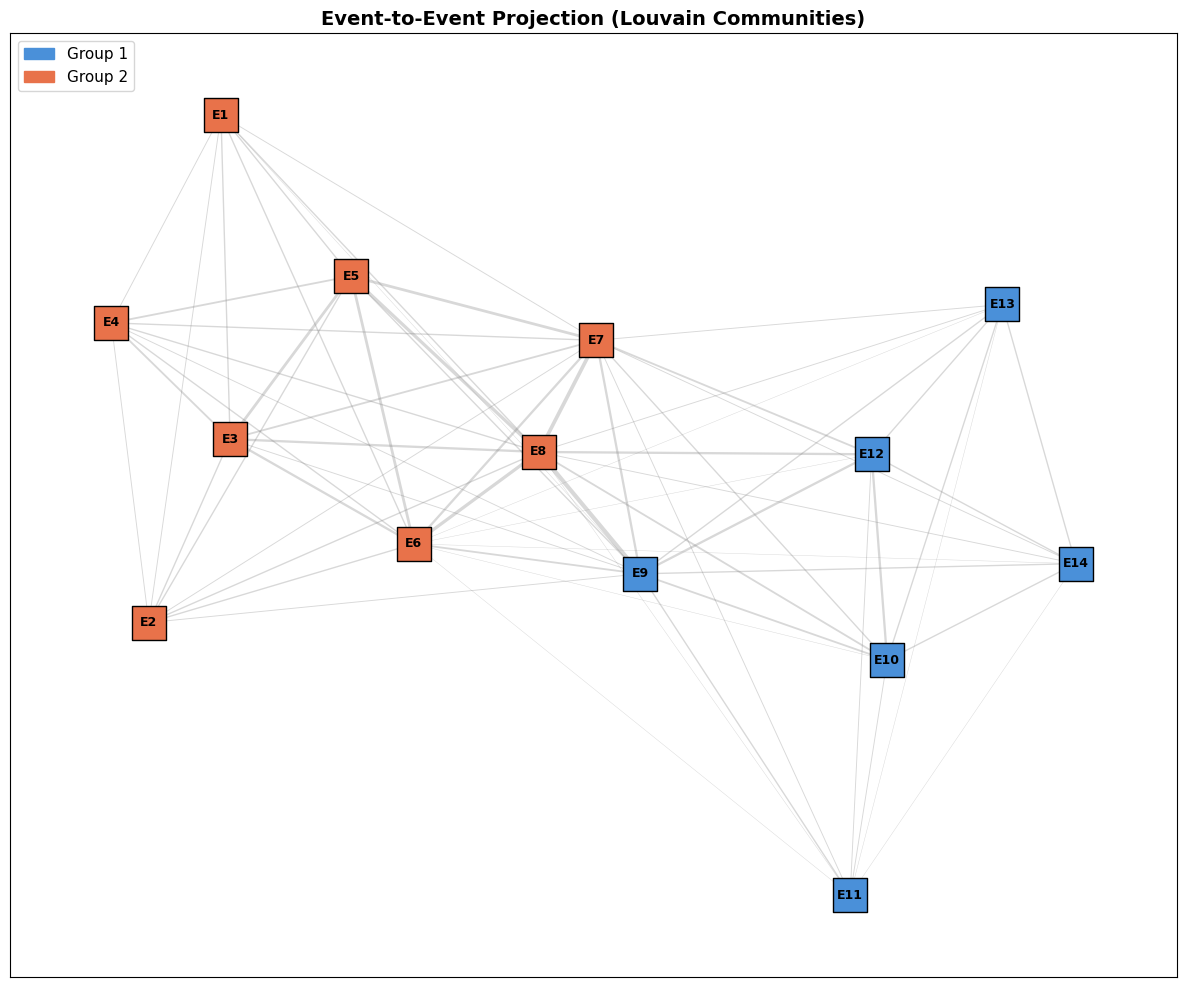

In [9]:
# Visualize events network
node_colors_e = [community_colors_map.get(partition_events[n], '#888888') for n in E.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
pos_e = nx.spring_layout(E, seed=42, k=1.0)
edges_e = E.edges(data=True)
edge_weights_e = [d['weight'] for _, _, d in edges_e]
max_we = max(edge_weights_e)

nx.draw_networkx_edges(E, pos_e, alpha=0.3, width=[w/max_we*3 for w in edge_weights_e], edge_color='gray', ax=ax)
nx.draw_networkx_nodes(E, pos_e, node_color=node_colors_e, node_size=600, node_shape='s', edgecolors='black', linewidths=1.0, ax=ax)
nx.draw_networkx_labels(E, pos_e, font_size=9, font_weight='bold', ax=ax)

patches_e = [mpatches.Patch(color=community_colors_map[c], label=f'Group {c+1}') for c in sorted(event_communities)]
ax.legend(handles=patches_e, loc='upper left', fontsize=11)
ax.set_title('Event-to-Event Projection (Louvain Communities)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Event centrality
deg_cent_e = nx.degree_centrality(E)
betw_cent_e = nx.betweenness_centrality(E, weight='weight')
eigen_cent_e = nx.eigenvector_centrality(E, weight='weight', max_iter=1000)

print(f"{'Event':<10} {'Degree':>8} {'Betweenness':>12} {'Eigenvector':>12}")
print("-" * 45)
for e in events_sorted:
    print(f"{e:<10} {deg_cent_e[e]:>8.3f} {betw_cent_e[e]:>12.3f} {eigen_cent_e[e]:>12.3f}")

print(f"\nMost central event by eigenvector: {max(eigen_cent_e, key=eigen_cent_e.get)}")
print(f"Most central event by betweenness: {max(betw_cent_e, key=betw_cent_e.get)}")

Event        Degree  Betweenness  Eigenvector
---------------------------------------------
E1            0.615        0.048        0.168
E10           0.615        0.000        0.187
E11           0.615        0.093        0.101
E12           0.615        0.000        0.216
E13           0.615        0.011        0.132
E14           0.615        0.011        0.132
E2            0.615        0.025        0.177
E3            0.615        0.000        0.277
E4            0.615        0.000        0.203
E5            0.615        0.000        0.333
E6            1.000        0.292        0.339
E7            1.000        0.029        0.377
E8            1.000        0.014        0.453
E9            1.000        0.124        0.352

Most central event by eigenvector: E8
Most central event by betweenness: E6


## 5. Validation: Hierarchical Clustering and Co-occurrence Heatmaps

As a validation check, hierarchical clustering on the co-occurrence matrices should produce groupings consistent with what Louvain found.

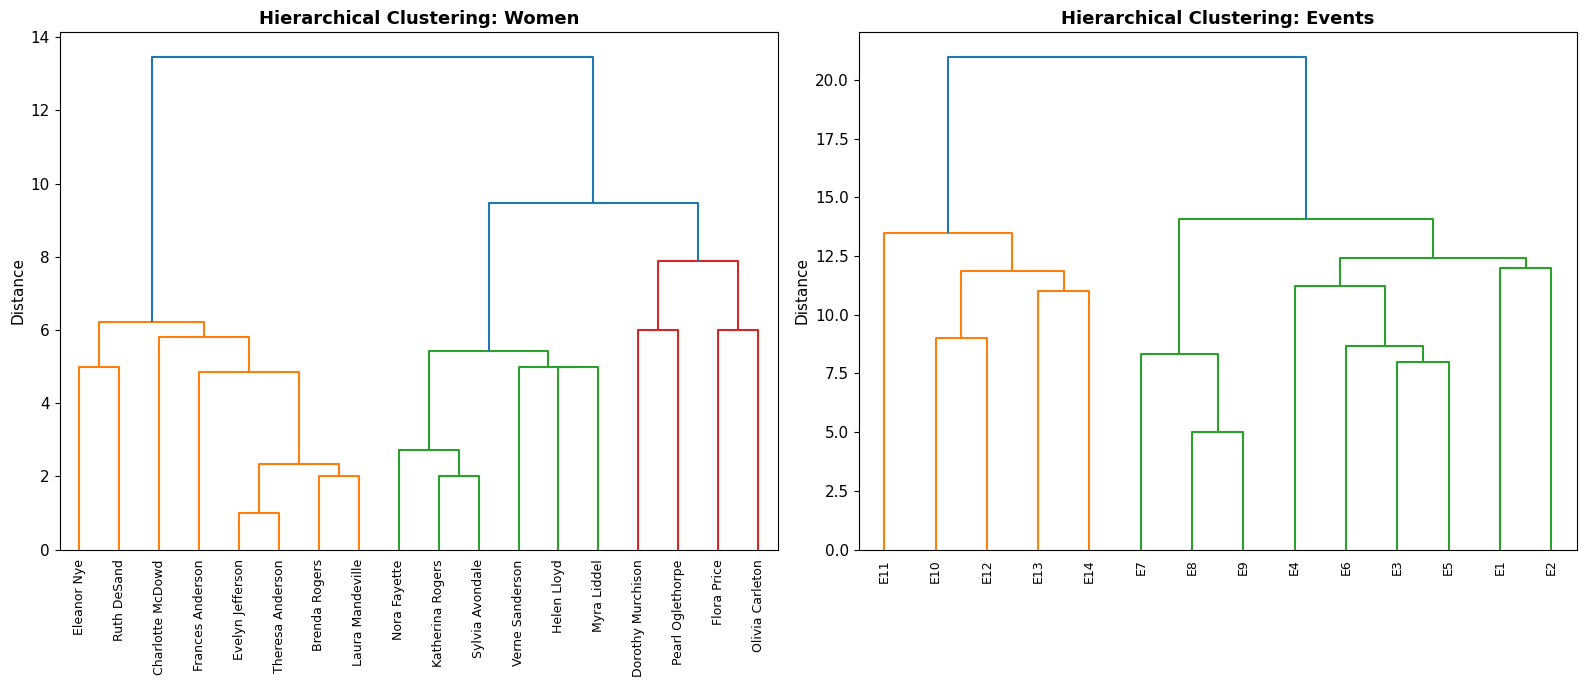

In [11]:
# Co-occurrence matrices and hierarchical clustering
co_women = adj_matrix @ adj_matrix.T
co_events = adj_matrix.T @ adj_matrix

# Women clustering
dist_women = co_women.max() - co_women
np.fill_diagonal(dist_women, 0)
Z_women = linkage(squareform(dist_women), method='ward')

# Events clustering
dist_events = co_events.max() - co_events
np.fill_diagonal(dist_events, 0)
Z_events = linkage(squareform(dist_events), method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
dendrogram(Z_women, labels=women_sorted, leaf_rotation=90, leaf_font_size=9, ax=axes[0])
axes[0].set_title('Hierarchical Clustering: Women', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Distance')

dendrogram(Z_events, labels=events_sorted, leaf_rotation=90, leaf_font_size=9, ax=axes[1])
axes[1].set_title('Hierarchical Clustering: Events', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Distance')
plt.tight_layout()
plt.show()

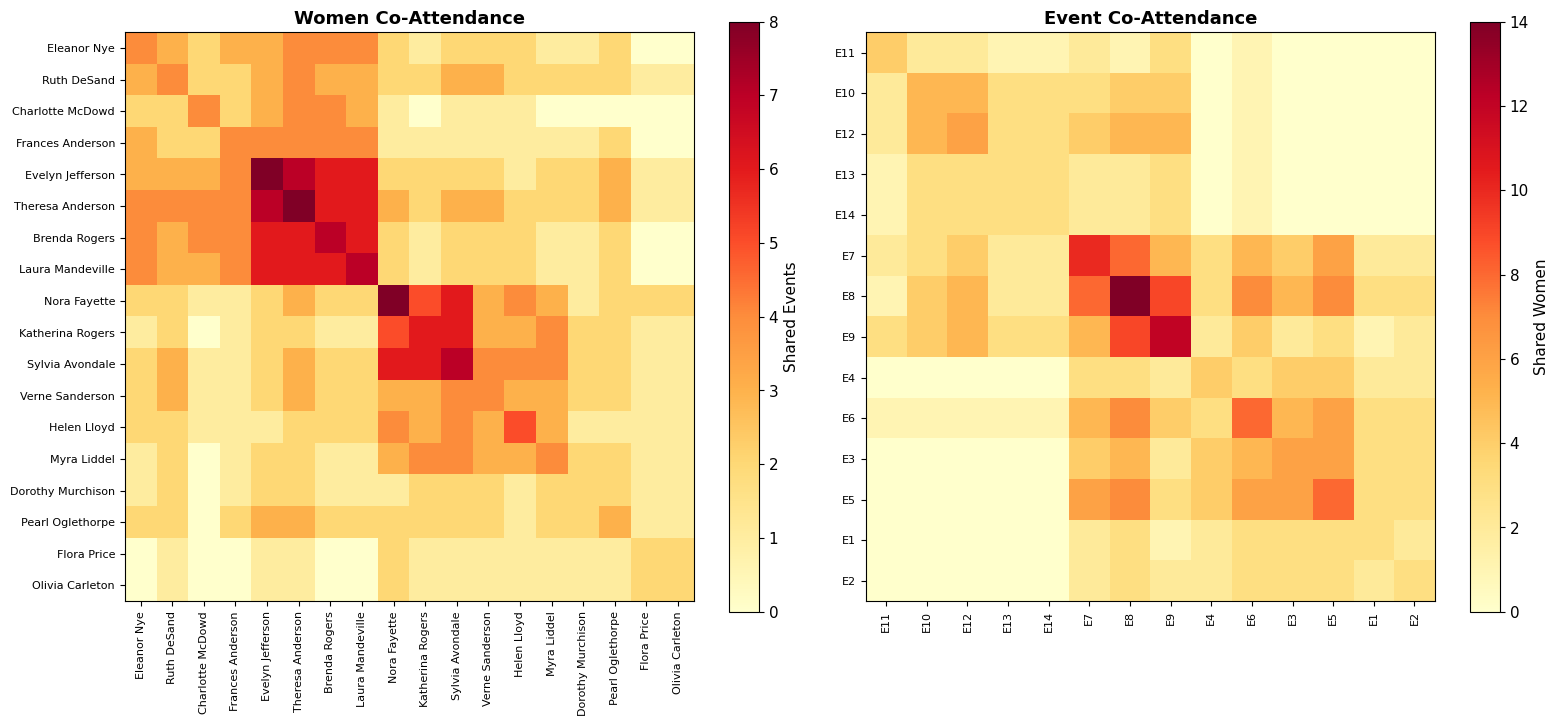

In [12]:
# Co-occurrence heatmaps reordered by cluster
women_order = leaves_list(Z_women)
events_order = leaves_list(Z_events)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

im1 = axes[0].imshow(co_women[np.ix_(women_order, women_order)], cmap='YlOrRd')
axes[0].set_xticks(range(len(women_sorted)))
axes[0].set_xticklabels([women_sorted[i] for i in women_order], rotation=90, fontsize=8)
axes[0].set_yticks(range(len(women_sorted)))
axes[0].set_yticklabels([women_sorted[i] for i in women_order], fontsize=8)
axes[0].set_title('Women Co-Attendance', fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Shared Events')

im2 = axes[1].imshow(co_events[np.ix_(events_order, events_order)], cmap='YlOrRd')
axes[1].set_xticks(range(len(events_sorted)))
axes[1].set_xticklabels([events_sorted[i] for i in events_order], rotation=90, fontsize=8)
axes[1].set_yticks(range(len(events_sorted)))
axes[1].set_yticklabels([events_sorted[i] for i in events_order], fontsize=8)
axes[1].set_title('Event Co-Attendance', fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Shared Women')
plt.tight_layout()
plt.show()

## 6. Analysis and Inferences

### Women

Louvain and hierarchical clustering both converge on the same **two-group partition**, consistent with decades of prior work on this dataset.

**Group 1** (Evelyn, Laura, Theresa, Brenda, Charlotte, Frances, Eleanor, Pearl, Ruth) skews toward earlier events (E1 through E8). Evelyn and Theresa are the most active at 8 events each, sharing 7 of them, the strongest co-attendance pair in the network.

**Group 2** (Verne, Myra, Katherine, Sylvia, Nora, Helen, Dorothy, Olivia, Flora) clusters around later events (E6 through E14). Nora leads this group with 8 events, her strongest tie being with Sylvia at 6 shared events.

What stands out in the centrality analysis is the divergence between **betweenness** and **eigenvector** measures. Flora Price and Olivia Carleton each attended only 2 events but have the highest betweenness (0.136 each) because those events spanned both groups, giving them disproportionate brokerage. Meanwhile, Theresa Anderson (0.354 eigenvector, 0.001 betweenness) is the most socially embedded woman but connects people who are already well-connected to each other. Textbook example of how different centrality measures capture fundamentally different social roles.

### Events

Events mirror the women's structure. **Cluster 1** (E1 through E8) maps to Group 1, **Cluster 2** (E9 through E14) maps to Group 2. E8 is the largest gathering (14 attendees, highest eigenvector at 0.453), while E6 has the highest betweenness (0.292), making it the key bridge event. The smaller events at the extremes (E1, E2, E13, E14 at 3 attendees each) reinforce the separateness of the two groups.

### Takeaways

Attendance patterns alone, without any explicit friendship data, reveal clear latent community structure. Both community detection and hierarchical clustering agree on the partition, the co-occurrence heatmaps make the block-diagonal structure visually obvious, and centrality analysis adds nuance by distinguishing embedded individuals from structural brokers. The fact that a dataset from 1941 still produces clean, interpretable results across modern algorithms is exactly why it remains a benchmark.